# Módulo 02: Modelagem Preditiva e Interpretabilidade de Salários em Dados

##Objetivo
Este caderno busca construir um modelo de Machine Learning (Regressão Linear) para prever a faixa salarial de profissionais da área de Dados no Brasil e, principalmente, compreender os **fatores socioeconômicos e profissionais que mais impactam o rendimento** (positiva ou negativamente).

---

##Pipeline de Trabalho
1. **Tratamento e Feature Engineering:** Padronização de variáveis categóricas, numéricas e ordinais.
2. **Pré-processamento:** One-Hot Encoding e Padronização (StandardScaler).
3. **Treinamento e Avaliação:** Regressão Linear com métricas $R^2$, MAE e MSE.
4. **Interpretabilidade:** Análise dos coeficientes do modelo para geração de *insights*.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

In [3]:
dados = pd.read_excel('/content/drive/MyDrive/PYTHON/PROGRAMARIA/MOD7_REGRESSAO LINEAR.xlsx')

In [4]:
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,0.0,1.0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,0.0,1.0


In [5]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

---
##  1. Engenharia de Recursos & Mapeamento de Dados

Nesta etapa, ajustamos os dados brutos recebidos da base tratada:
* Mapeamento de variáveis demográficas (COR/RACA/ETNIA para NAO_BRANCA).
* Extração numérica de TEMPO_EXPERIENCIA e NUMERO DE FUNCIONARIOS.
* Transformação ordinal da escolaridade (NIVEL DE ENSINO) em escala quantitativa.
* Criação da variável de engajamento/satisfação baseada no motivo de insatisfação salarial.

In [6]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762
Empreendedor ou Empregado (CNPJ),410
"Desempregado, buscando recolocação",350
Estagiário,188
Servidor Público,156
Trabalho na área Acadêmica/Pesquisador,86
Somente Estudante (graduação),82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil,69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil,46


In [7]:
dados = dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?']=='Empregado (CLT)']

In [8]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762


In [9]:
dados['COR/RACA/ETNIA'].value_counts()

,count
COR/RACA/ETNIA,
Branca,1805
Parda,661
Preta,181
Amarela,85
Prefiro não informar,16
Outra,10
Indígena,4


In [10]:
#Retirar indigena - amostra muito baixa
#Retirar Outra e Prefiro nao informar
lista_retirar = ['Prefiro não informar', 'Outra', 'Indígena']

In [11]:
#~ na funcao faz o contrario do que pede a funcao
#isin esta em - o ~ retira o que esta na lista
dados = dados[~dados['COR/RACA/ETNIA'].isin(lista_retirar)]

In [12]:
#criar uma coluna para pessoas nao branca
#vamos agrupar brancos e nao brancos
dados['NAO_BRANCA']= dados['COR/RACA/ETNIA'].apply(lambda x: 1 if x!= 'Branca' else  0)

In [13]:
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts()

,count
QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,
de 1 a 2 anos,743
de 3 a 4 anos,584
de 4 a 6 anos,416
Menos de 1 ano,353
Mais de 10 anos,277
de 7 a 10 anos,232
Não tenho experiência na área de dados,127


In [14]:
#CRIAMOS UMA COLUNA COM TEMPO DE EXPERIENCIA
#PEGANDO O PRIMEIRO DIGITO DE CADA FRASE
dados['TEMPO_EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')

In [15]:
dados['TEMPO_EXPERIENCIA'].value_counts()

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232


In [16]:
#Aqui retiramos o . que existia nos numeros para fazer o mesmo extract anterior
dados['NUMERO DE FUNCIONARIOS']= dados['NUMERO DE FUNCIONARIOS'].str.replace('.','')

In [17]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
Acima de 3000,1313
de 101 a 500,503
de 1001 a 3000,368
de 501 a 1000,248
de 51 a 100,146
de 11 a 50,112
de 6 a 10,24
de 1 a 5,18


In [18]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

In [19]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

,count
NUMERO DE FUNCIONARIOS,
3000,1313
101,503
1001,368
501,248
51,146
11,112
6,24
1,18


In [20]:
#O NaN REPRESENTA AS PESSOAS SEM EXPERIENCIA NA AREA DE DADOS
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
NaN,127


In [21]:
#VAMOS  INCLUIR AS PESSOAS SEM EXPERIENCIA, COLOCANDO ZERO
dados['TEMPO_EXPERIENCIA'] = dados['TEMPO_EXPERIENCIA'].fillna(0)

In [22]:
dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts()

,count
Qual o principal motivo da sua insatisfação com a empresa atual?,
Gostaria de trabalhar em em outra área de atuação,69
Salário atual não corresponde ao mercado,53
Falta de oportunidade de crescimento no emprego atual,46
Falta de maturidade analítica na empresa,45
"Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa",26
...,...
"O clima de trabalho/ambiente não é bom, Não tenho uma boa relação com meu líder/gestor, Gostaria de receber mais benefícios",1
Falta de organização nos processos internos,1
"Gostaria de receber mais benefícios, O clima de trabalho/ambiente não é bom, Falta de oportunidade de crescimento no emprego atual",1


In [23]:
#ciar uma coluna com insatisfacao
#criar uma coluna com insatisfacao com salario
#tudo que e insatisfacao = 0
dados['INSATISFACAO'] = 0

In [24]:
#tiramos os as entradas nulas
#se tiver salario envolvido na resposta = 1
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFACAO'] = dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

In [25]:
dados['INSATISFACAO'].value_counts()

,count
INSATISFACAO,
0,2453
1,279


In [26]:
dados['NIVEL DE ENSINO'].value_counts()

,count
NIVEL DE ENSINO,
Graduação/Bacharelado,1024
Pós-graduação,975
Mestrado,306
Estudante de Graduação,271
Doutorado ou Phd,100
Não tenho graduação formal,52
Prefiro não informar,4


In [27]:
dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x == 'Não tenho graduação formal' else
                               1 if x == 'Estudante de Graduação' else
                               2 if x == 'Graduação/Bacharelado'else
                               3 if x == 'Pós-graduação' else
                               4 if x== 'Mestrado' else
                               5 if x== 'Doutorado ou Phd' else -1)


In [28]:
dados['NIVEL DE ENSINO'].value_counts()

,count
NIVEL DE ENSINO,
2,1024
3,975
4,306
1,271
5,100
0,52
-1,4


In [29]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [30]:
dados = dados[['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL']]

In [31]:
dados.columns

Index(['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
       'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL'],
      dtype='object')

---
##  2. Pré-processamento e Modelagem Preditiva

Para preparar os dados para o algoritmo de Regressão Linear:
1. Aplica-se **One-Hot Encoding** (pd.get_dummies) para variáveis categóricas de setor, gênero e cargo.
2. Divisão da base em **Treino (80%)** e **Teste (20%)** para evitar *data leakage*.
3. **Escalonamento:** Uso do StandardScaler ajustado apenas nos dados de treino para colocar todas as variáveis na mesma escala.

In [32]:
dados = pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'],drop_first=True )

In [33]:
x = dados.drop('SALARIO', axis =1)
y = dados['SALARIO']

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
model = LinearRegression()

In [40]:
model.fit(x_train_scaled, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(x_test_scaled)

---
## 3. Avaliação de Desempenho do Modelo

* $R^2$ Score (~0.53): O modelo consegue explicar aproximadamente **53% da variância dos salários** com base nas variáveis utilizadas.
* MAE (~3.298,96): Em média, as previsões do modelo erram cerca de 3,3k do valor real.
* Leitura da Dispersão:O gráfico mostra boa aderência na faixa salarial média (5k a 20k), porém o modelo tende a subestimar salários muito altos (outliers acima de 30k).

In [42]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [43]:
#erro muito alto
mse = mean_squared_error(y_test, y_pred)
mse

23048733.978297196

In [44]:
#erro medio absoluto
mae = mean_absolute_error(y_test, y_pred)
mae

3298.964464206939

In [45]:
r2 = r2_score(y_test, y_pred)
r2


0.5297347873934934

---
## 4. Visualização de Resultados e Interpretação do Modelo

Abaixo, analisamos o comportamento do modelo através de duas visualizações fundamentais:

1. **Dispersão (Valor Real vs. Valor Predito):** Avalia a precisão do modelo ao longo das faixas salariais e identifica desvios ou limitações da Regressão Linear.
2. **Gráfico de Coeficientes:** Exibe o peso e a direção (positiva ou negativa) de cada variável padronizada na previsão do salário final.

In [46]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

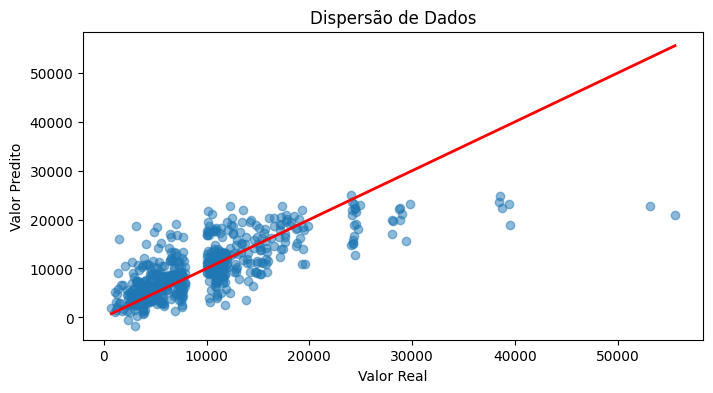

In [47]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predito')
plt.title('Dispersão de Dados')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.show

In [48]:
nome_atributos = x_train.columns
nome_atributos

Index(['IDADE', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'GENERO_Masculino',
       'GENERO_Prefiro não informar', 'SETOR_Educação',
       'SETOR_Entretenimento ou Esportes', 'SETOR_Filantropia/ONG's',
       'SETOR_Finanças ou Bancos', 'SETOR_Indústria',
       'SETOR_Internet/Ecommerce', 'SETOR_Marketing', 'SETOR_Outra Opção',
       'SETOR_Seguros ou Previdência', 'SETOR_Setor Alimentício',
       'SETOR_Setor Automotivo', 'SETOR_Setor Farmaceutico',
       'SETOR_Setor Imobiliário/ Construção Civil', 'SETOR_Setor Público',
       'SETOR_Setor de Energia', 'SETOR_Tecnologia/Fábrica de Software',
       'SETOR_Telecomunicação', 'SETOR_Varejo', 'SETOR_Área da Saúde',
       'SETOR_Área de Consultoria', 'NOVO_NIVEL_Pessoa Gestora',
       'NOVO_NIVEL_Pleno', 'NOVO_NIVEL_Sênior', 'REGIAO ONDE MORA_Nordeste',
       'REGIAO ONDE MORA_Norte', 'REGIAO ONDE MORA_Sudeste',
       'REGIAO ONDE MORA_Sul'],
      dtype='object')

In [49]:
coefs = pd.DataFrame(model.coef_, columns=['coeficientes'], index= nome_atributos)

In [50]:
coefs = coefs.sort_values(by= 'coeficientes', ascending=False)

In [51]:
coefs

,coeficientes
NOVO_NIVEL_Pessoa Gestora,3965.837560
NOVO_NIVEL_Sênior,2008.062980
TEMPO_EXPERIENCIA,2004.015472
NOVO_NIVEL_Pleno,900.352033
NIVEL DE ENSINO,843.824926
NUMERO DE FUNCIONARIOS,797.206111
SETOR_Finanças ou Bancos,727.227138
SETOR_Internet/Ecommerce,693.103642
SETOR_Tecnologia/Fábrica de Software,637.817363
GENERO_Masculino,555.450771


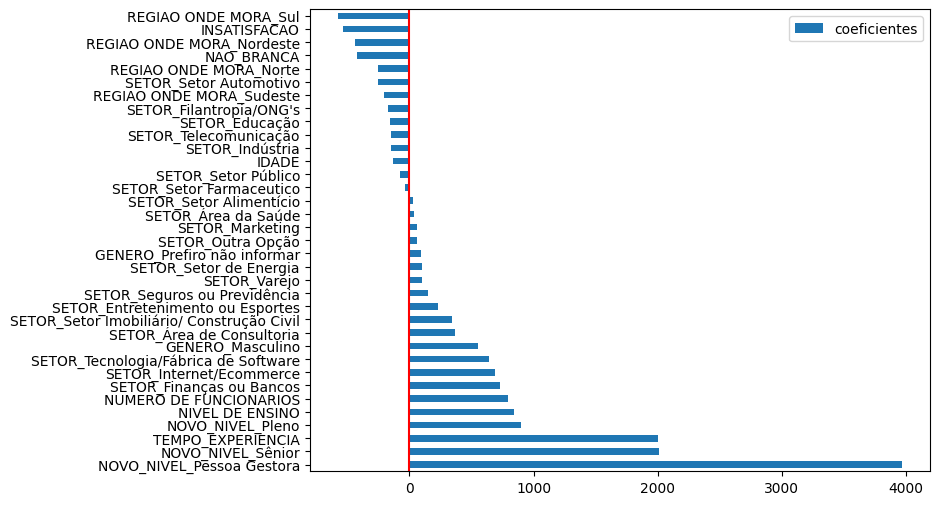

In [52]:
coefs.plot.barh(figsize=(8,6))
plt.axvline(x=0, color='red')

---
## 5. Análise Final & Insights Socioeconômicos

Com base nos coeficientes da Regressão Linear padronizada, podemos extrair as seguintes conclusões estratégicas sobre a estrutura salarial do mercado de dados:

### Principais Fatores Positivos (Maior impacto no aumento salarial):
* **Cargo e Sênioridade:** Atuar em cargos de **Gestão**  e **Sênior**
* **Experiência e Formação:** Anos de experiência técnica em dados e grau de escolaridade apresentam forte relação positiva com a remuneração.
* **Setores de Destaque:** O segmento de *Finanças/Bancos*, *E-commerce* e *Tecnologia* pagam prêmios salariais acima da média do mercado.

### Principais Impactos Negativos e Desigualdades:
* **Disparidades Socioeconômicas:** A variável não branca e a localização geográfica fora do Sudeste apresentaram coeficientes negativos no modelo.
* **Setores com Menor Remuneração:** O setor de **Indústria** e segmentos como *Telecomunicação*, *Educação* e *Filantropia/ONGs* apresentaram coeficientes negativos no modelo, indicando uma média salarial inferior quando comparados aos setores de Tecnologia e Finanças.
---
